In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import torch
import torch.nn as nn   
import torch.optim as optim

from torch.optim import SGD

from torch.utils.data import DataLoader, TensorDataset

Input and target data:

Masking the wavelength grid

In [3]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

In [4]:
low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [ ]:
preprocessed_flux = np.load("../preprocessing/cflib_data.npz", allow_pickle= True)["flux"]

input_flux = []

for i in range(len(preprocessed_flux)):
    input_flux.append(preprocessed_flux[i][low_idx : high_idx + 1])
    
input_flux = np.array(input_flux)

# input_flux = np.load("../preprocessing/preprocess_cflib_vyom.npy")   # input of vyom preprocessed data

target_flux = np.load("rf_interpolated_fluxes.npy")

print(len(target_flux[0]))  # checking the length of the interpolated flux arrays
print(input_flux)
print(target_flux)


4306
[[1.1825487646914092 1.1841432511841439 1.1860783470682998 ...
  0.4124035574007773 0.4105880111693166 0.4107658742488486]
 [0.05012359158249259 0.05087644314420091 0.05242872825483944 ...
  1.470013205194036 1.4559561793877915 1.4632705648224837]
 [0.2362234472559823 0.23218703652067837 0.23380249477842624 ...
  0.7866333409396982 0.7716400516481633 0.7752994451876409]
 ...
 [0.6531245140554456 0.6494315947886485 0.6536496646603588 ...
  9.85354519046036e-05 9.85354519046036e-05 9.85354519046036e-05]
 [0.40733122403375077 0.38788939127494076 0.39513174101918763 ...
  9.190256391646997e-05 9.190256391646997e-05 9.190256391646997e-05]
 [0.6186189577056762 0.622308238396077 0.6300363299913472 ...
  0.6388013675444142 0.6380960935140043 0.6365599939693225]]
[[1.18601767 1.22942634 1.17626099 ... 0.42062923 0.42171141 0.42278666]
 [0.09260631 0.10392712 0.1085579  ... 1.89134097 1.89760813 1.91798774]
 [0.12836964 0.1376427  0.13979537 ... 0.82752983 0.81743293 0.82009242]
 ...
 [0.78

Checking for the order of the flux data of stars

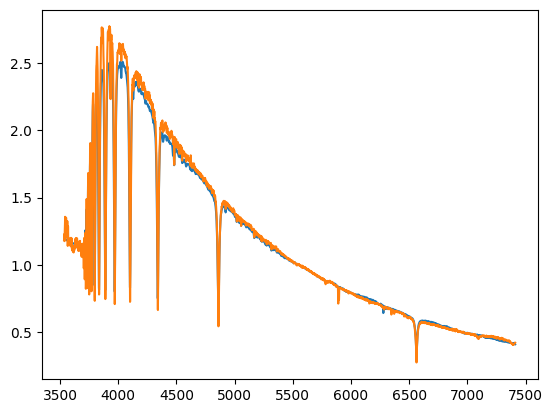

In [8]:
plt.plot(final_wave,input_flux[0])
plt.plot(final_wave,target_flux[0])

In [ ]:
input_flux = np.array(input_flux, dtype=np.float32)    

numpy.ndarray

Splitting the data in training and testing data : 

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input_flux,target_flux, test_size= 0.2, random_state = 42)

Switching from CPU cores to CUDA cores :

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Initializing the Denoising Auto Encoder :

In [12]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim = 4306, latent_dim = 128):
        super(DenoisingAutoencoder, self).__init__()

        # initializing the latent space (bottle neck for the network)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024,2048),
            nn.ReLU(),
            nn.Linear(2048,4306)
        )

    # x here is a datapoint --> in our case a rank one tensor (datapoint vector)
    
    def forward(self, x):       
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

def add_noise(x, noise_factor = 0.01):      # add a gaussian noise to the data vector 
    noise = noise_factor * torch.randn_like(x)       # choose a random tensor with a same shape as X from a standard normal distribution
    return x + noise
    


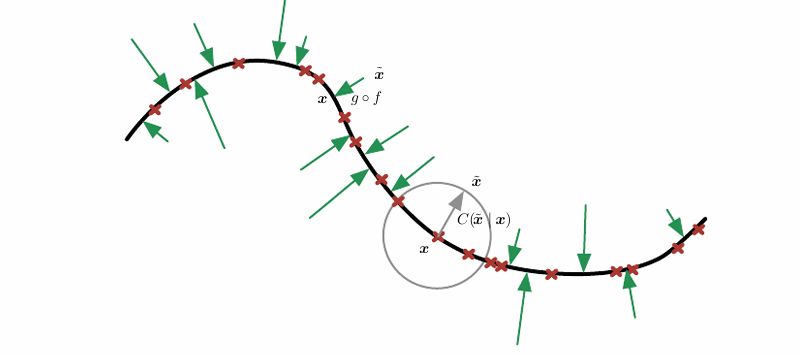

The gray circle is the noise circle that has noise mappings of real input values on the circumference.

Defining the model 

In [ ]:
model = DenoisingAutoencoder(input_dim = 4306, latent_dim= 128)
model.to(device)    # shifting the model to CUDA cores

In [14]:
model.parameters()

<generator object Module.parameters at 0x7c264994e260>

Initializing the ADAM optimizer 

In [21]:
optimizer = optim.Adam(model.parameters(), lr= 1e-3)

loss_fn = nn.MSELoss()      # MSE as the loss functon


In [ ]:
X_tensor = torch.tensor(X_train, dtype= torch.float32).to(device= device)       # converting the input data to tensor , in out case , each input datapoint is a rank 1 tensor (vector)
y_tensor = torch.tensor(y_train, dtype= torch.float32).to(device= device)

dataset = TensorDataset(X_tensor,y_tensor)

In [ ]:
dataset = TensorDataset(X_tensor, y_tensor)  # creating a joint pair 
loader = DataLoader(dataset, batch_size=32, shuffle=True)   # wraps the dataset and enables mini-batch training 

Training loop and optimizing model parameters using backpropagation and ADAM :

In [ ]:
for epoch in range(1,501):
    model.train()           # training the model in each epoch
    running_loss = 0      # initializing a running loss for each epoch

    for x_batch,y_batch in loader:          # running loop for different batches in each epoch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        noisy_input = add_noise(x_batch)           # adding noise to the input batch
        output = model(noisy_input)

        loss = loss_fn(output, y_batch)     # calculating the loss function for each batch in an epoch 

        optimizer.zero_grad()       # clears the gradients from previous batch
        loss.backward()         # computes the gradient of the loss function with respect to the parameter/s we want to optimize
        optimizer.step()       # take a small step towards the better value of the parameter

        running_loss += loss        # summing up total loss of all the batches

    print(f"Epoch number : {epoch}, loss = {running_loss}")

    if running_loss < 0.05:     # setting up a threshold for epochs (early stopping)
        break   

    

Epoch number : 1, loss = 35.04235076904297
Epoch number : 2, loss = 6.477858066558838
Epoch number : 3, loss = 3.5430405139923096
Epoch number : 4, loss = 3.2770955562591553
Epoch number : 5, loss = 3.2120285034179688
Epoch number : 6, loss = 3.22088623046875
Epoch number : 7, loss = 3.273298978805542
Epoch number : 8, loss = 3.216829538345337
Epoch number : 9, loss = 3.193268299102783
Epoch number : 10, loss = 3.1372909545898438
Epoch number : 11, loss = 3.1286683082580566
Epoch number : 12, loss = 3.043250322341919
Epoch number : 13, loss = 2.3926234245300293
Epoch number : 14, loss = 1.1850577592849731
Epoch number : 15, loss = 1.0561742782592773
Epoch number : 16, loss = 0.9875928163528442
Epoch number : 17, loss = 0.8536467552185059
Epoch number : 18, loss = 0.801260769367218
Epoch number : 19, loss = 0.7696533203125
Epoch number : 20, loss = 1.1050896644592285
Epoch number : 21, loss = 0.8964256048202515
Epoch number : 22, loss = 0.8467445969581604
Epoch number : 23, loss = 0.610